# DSR-figures playground
Publication figures for the fMRI DSR (action-plan) effect.

## 0. Setup

In [1]:
%matplotlib inline
import sys, os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/multiple_clocks_repo')
sys.path.insert(0, str(REPO))
import era_brewer

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
print('OK')

OK


## 1. Paths — edit these for new runs

In [2]:
RESULTS = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/data/final_results/fMRI_dsr')
STATS_DSR = RESULTS / 'fig_dsr_roi_betas_stats.json'
print('Stats JSON:', STATS_DSR)
print('Exists?   ', STATS_DSR.exists())

Stats JSON: /Users/xpsy1114/Documents/projects/multiple_clocks/data/final_results/fMRI_dsr/fig_dsr_roi_betas_stats.json
Exists?    True


## 2. PLOT A — fMRI DSR ROI-mean betas (full bilateral mask)
Mean β per subject within bilateral anatomical ROI masks (mPFC, lateral OFC) plus an FFA control sphere. FWE correction: whole-brain cluster-level FWE on the group t-stat map. Stats and figure data come from `fig_dsr_roi_betas_stats.json` (see `scripts/get_subj_effects_fMRI.py`). Stars on the figure reflect the descriptive within-ROI one-sample t-test against zero; FWE-corrected p-values are printed below the figure.

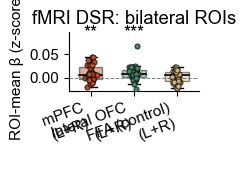

FWE correction: whole-brain cluster-level FWE  |  n=33

ROI-mean per-subject one-sample t-tests:
  mPFC              L+R  nvox=4273   mean=+0.00846  t=+2.84  p=0.0039  **
  lateral OFC       L+R  nvox=3505   mean=+0.00954  t=+3.51  p=0.0007  ***
  FFA (control)     L+R  nvox=112    mean=+0.00259  t=+1.21  p=0.1167  n.s.

FWE-significant peaks:
  rank 1: MNI=(-38,+28,-14)  peak t=4.94  cluster=1226 vox  FWE p≤0.0210  inside=lateral OFC
  rank 2: MNI=(+2,+50,+18)  peak t=3.85  cluster=960 vox  FWE p≤0.0420  inside=mPFC


In [3]:
# Re-plot ROI-mean betas from the saved stats JSON so the figure stays editable.
STATS = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/data/final_results/fMRI_dsr/fig_dsr_roi_betas_stats.json')
with open(STATS) as f:
    stats_d = json.load(f)

pass_data = stats_d['pass1_full_mask']
region_order = list(pass_data.keys())
palette = era_brewer.era_brew('Showgirl2', n=max(len(region_order), 5))

fig, ax = plt.subplots(figsize=(5/2.54, 4/2.54), constrained_layout=True)
positions = np.arange(len(region_order)) + 1
box_data = [np.asarray(pass_data[r]['values'], float) for r in region_order]
bp = ax.boxplot(box_data, positions=positions, widths=0.55,
                showfliers=False, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.2))
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c); patch.set_alpha(0.45); patch.set_edgecolor('black')
rng = np.random.default_rng(42)
for i, (d, c) in enumerate(zip(box_data, palette)):
    jitter = 0.07 * rng.standard_normal(d.size)
    ax.scatter(positions[i] + jitter, d, s=14, color=c,
               edgecolor='black', linewidth=0.5, zorder=3)
ax.axhline(0, color='gray', ls='--', lw=0.7)
ax.set_xticks(positions)
labels = [f"{r}\n({pass_data[r]['hemisphere'] or 'L+R'})" for r in region_order]
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('ROI-mean β (z-scored)')
ax.set_title('fMRI DSR: bilateral ROIs')
for sp in ('top','right'): ax.spines[sp].set_visible(False)
ymin, ymax = ax.get_ylim()
scale = ymax - ymin
star_y = ymax + scale * 0.04
for i, r in enumerate(region_order):
    s = pass_data[r]['sig']
    if s == 'n.s.':
        continue
    ax.text(positions[i], star_y, s, ha='center', va='bottom', fontsize=13)
ax.set_ylim(ymin, star_y + scale * 0.20)
plt.show()

print(f"FWE correction: {stats_d['settings']['fwe_correction_mode']}  |  n={stats_d['inputs']['n_subjects']}")
print('\nROI-mean per-subject one-sample t-tests:')
for r in region_order:
    rs = pass_data[r]
    h = rs['hemisphere'] or 'L+R'
    print(f"  {r:16s} {h:>4s}  nvox={rs['n_voxels_in_mask']:<5d}  mean={rs['mean']:+.5f}  t={rs['t']:+.2f}  p={rs['p']:.4f}  {rs['sig']}")
print('\nFWE-significant peaks:')
for pk in stats_d['fwe_peaks']:
    print(f"  rank {pk['rank']}: MNI=({pk['mni'][0]:+.0f},{pk['mni'][1]:+.0f},{pk['mni'][2]:+.0f})"
          f"  peak t={pk['peak_tstat']:.2f}  cluster={pk['cluster_size_voxels']} vox"
          f"  FWE p≤{pk['fwe_p_min']:.4f}  inside={pk['inside_roi'] or '-'}")


## Next iteration ideas
- Add a brain-projection panel with the FWE-corrected cluster map.